<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week1_repricing/Week1_Repricing_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

In [4]:
!cp "/content/kaggle.json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!cat /root/.kaggle/kaggle.json

{"username":"sanjaykumarrajkumar","key":"a42be66e0e5b12b4dbf5bbb34e308d52"}

In [5]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data
!ls -la walmart_data

100% 2.70M/2.70M [00:00<00:00, 145MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  
total 18824
drwxr-xr-x 2 root root     4096 Jun 22 21:48 .
drwxr-xr-x 1 root root     4096 Jun 22 21:48 ..
-rw-r--r-- 1 root root   592289 Feb  3  2014 features.csv
-rw-r--r-- 1 root root   161700 Dec 11  2019 features.csv.zip
-rw-r--r-- 1 root root   225538 Dec 11  2019 sampleSubmission.csv.zip
-rw-r--r-- 1 root root      532 Dec 11  2019 stores.csv
-rw-r--r-- 1 root root  2598077 Feb  3  2014 test.csv
-rw-r--r-- 1 root root   240940 Dec 11  2019 

In [6]:
np.random.seed(42)

train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [7]:
def derive_price_index(df, dept_id, store_id, base_price=50):
    subset = df[(df["Dept"] == dept_id) & (df["Store"] == store_id)].copy()
    subset = subset.sort_values("Date").reset_index(drop=True)

    sales_norm = (subset["Weekly_Sales"] - subset["Weekly_Sales"].min()) / (
        subset["Weekly_Sales"].max() - subset["Weekly_Sales"].min()
    )
    subset["own_price"] = base_price * (1.2 - 0.4 * sales_norm)
    return subset[["Date", "Weekly_Sales", "own_price", "IsHoliday"]]

price_df = derive_price_index(df, dept_id=1, store_id=1)
print(price_df.shape)
price_df.head()

(143, 4)


,Date,Weekly_Sales,own_price,IsHoliday
0,2010-02-05,24924.50,55.174920,False
1,2010-02-12,46039.49,45.366483,True
2,2010-02-19,41595.55,47.430804,False
3,2010-02-26,19403.54,57.739543,False
4,2010-03-05,21827.90,56.613368,False


In [8]:
def simulate_competitor_price(own_price_series, volatility=0.015):
    n = len(own_price_series)
    shocks = np.random.normal(loc=0, scale=volatility, size=n)
    competitor_price = own_price_series.iloc[0] * (1 + np.cumsum(shocks))
    competitor_price = 0.7 * competitor_price + 0.3 * own_price_series.values
    return competitor_price

price_df["competitor_price"] = simulate_competitor_price(price_df["own_price"])
price_df.head()

,Date,Weekly_Sales,own_price,IsHoliday,competitor_price
0,2010-02-05,24924.50,55.174920,False,55.462685
1,2010-02-12,46039.49,45.366483,True,52.440052
2,2010-02-19,41595.55,47.430804,False,53.434578
3,2010-02-26,19403.54,57.739543,False,57.409547
4,2010-03-05,21827.90,56.613368,False,56.936041


In [9]:
def repricing_engine(own_price, competitor_price, undercut_pct=0.03, margin_floor=35):
    recommended = np.where(
        competitor_price < own_price,
        np.maximum(competitor_price * (1 - undercut_pct), margin_floor),
        own_price,
    )
    return recommended

price_df["recommended_price"] = repricing_engine(
    price_df["own_price"].values, price_df["competitor_price"].values
)
price_df["price_changed"] = price_df["recommended_price"] != price_df["own_price"]

change_rate = price_df["price_changed"].mean()
print(f"Repricing engine would have triggered a price change {change_rate:.1%} of weeks.")
price_df.head(10)

Repricing engine would have triggered a price change 88.1% of weeks.


,Date,Weekly_Sales,own_price,IsHoliday,competitor_price,recommended_price,price_changed
0,2010-02-05,24924.50,55.174920,False,55.462685,55.174920,False
1,2010-02-12,46039.49,45.366483,True,52.440052,45.366483,False
2,2010-02-19,41595.55,47.430804,False,53.434578,47.430804,False
3,2010-02-26,19403.54,57.739543,False,57.409547,55.687261,True
4,2010-03-05,21827.90,56.613368,False,56.936041,56.613368,False
5,2010-03-12,21043.39,56.977792,False,56.909724,55.202432,True
6,2010-03-19,22136.64,56.469950,False,57.672267,56.469950,False
7,2010-03-26,26229.21,54.568850,False,57.546540,54.568850,False
8,2010-04-02,57258.43,40.155007,False,52.950404,40.155007,False
9,2010-04-09,42960.91,46.796560,False,55.257195,46.796560,False


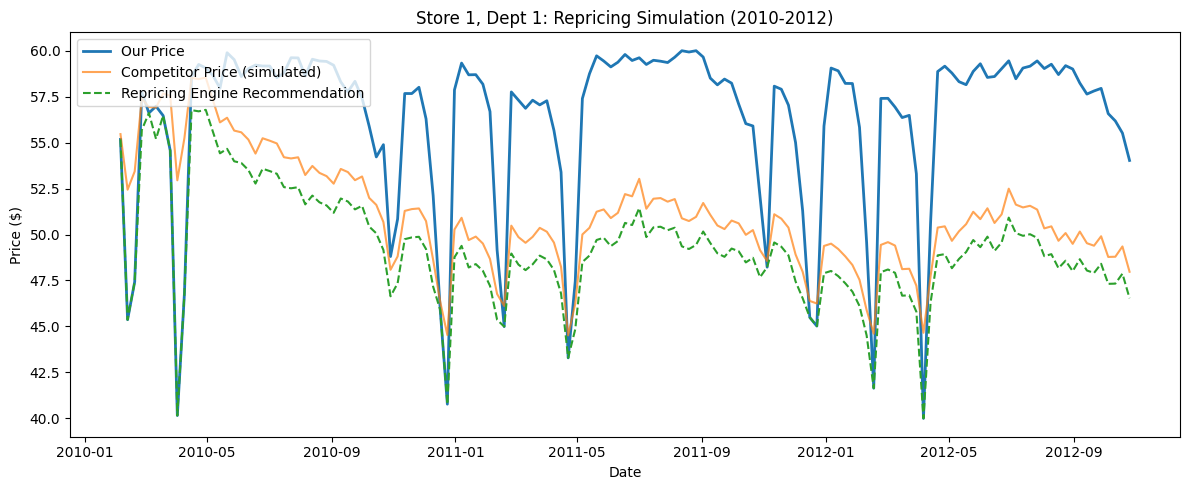

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(price_df["Date"], price_df["own_price"], label="Our Price", linewidth=2)
plt.plot(price_df["Date"], price_df["competitor_price"], label="Competitor Price (simulated)", linewidth=1.5, alpha=0.7)
plt.plot(price_df["Date"], price_df["recommended_price"], label="Repricing Engine Recommendation", linestyle="--", linewidth=1.5)
plt.title("Store 1, Dept 1: Repricing Simulation (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("week1_repricing_chart.png", dpi=150)
plt.show()

Showing the raw data gap

In [11]:
print("Columns in the merged Walmart dataset:")
print(df.columns.tolist())
print(f"\nTotal rows: {df.shape[0]}")
print(f"\nSample of key columns:")
print(df[["Store", "Dept", "Date", "Weekly_Sales", "MarkDown1", "MarkDown2", "MarkDown3"]].head(8).to_string())
print("\nKey gap: no unit price, no competitor price, no margin column.")
print("Weekly_Sales is revenue only, not volume x price broken out.")

Columns in the merged Walmart dataset:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

Total rows: 421570

Sample of key columns:
   Store  Dept       Date  Weekly_Sales  MarkDown1  MarkDown2  MarkDown3
0      1     1 2010-02-05      24924.50        NaN        NaN        NaN
1      1     1 2010-02-12      46039.49        NaN        NaN        NaN
2      1     1 2010-02-19      41595.55        NaN        NaN        NaN
3      1     1 2010-02-26      19403.54        NaN        NaN        NaN
4      1     1 2010-03-05      21827.90        NaN        NaN        NaN
5      1     1 2010-03-12      21043.39        NaN        NaN        NaN
6      1     1 2010-03-19      22136.64        NaN        NaN        NaN
7      1     1 2010-03-26      26229.21        NaN        NaN        NaN

Key gap: no unit price, no competitor price, no margin column.
Weekly_S

Visualizing Weekly_Sales vs derived own_price

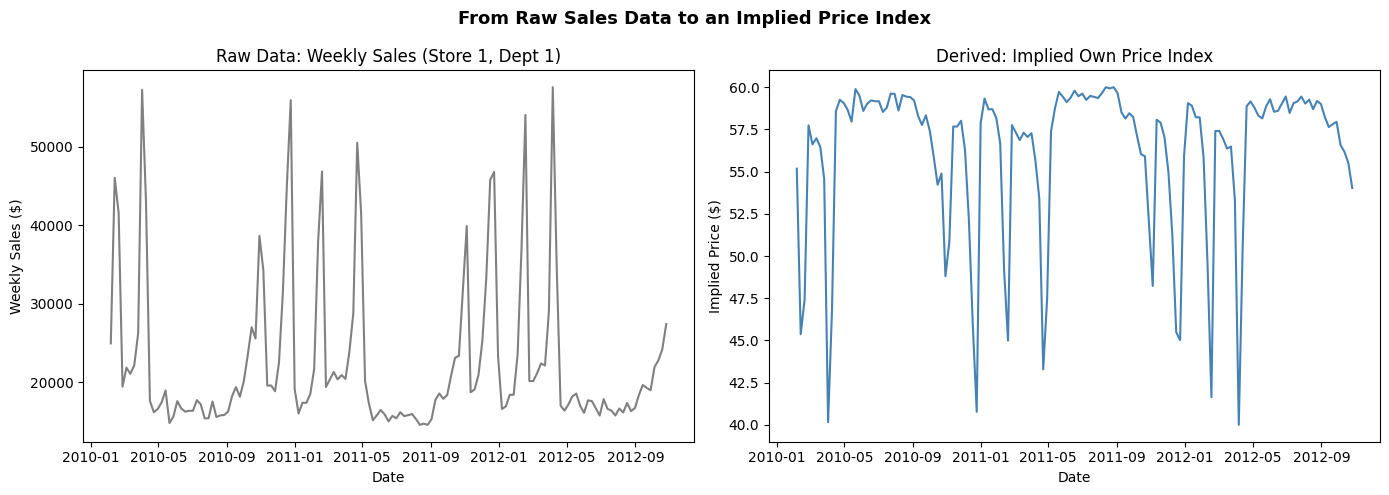

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(price_df["Date"], price_df["Weekly_Sales"], color="gray", linewidth=1.5)
axes[0].set_title("Raw Data: Weekly Sales (Store 1, Dept 1)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Weekly Sales ($)")

axes[1].plot(price_df["Date"], price_df["own_price"], color="steelblue", linewidth=1.5)
axes[1].set_title("Derived: Implied Own Price Index")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Implied Price ($)")

plt.suptitle("From Raw Sales Data to an Implied Price Index", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("week1_day2_derivation.png", dpi=150)
plt.show()

Showing how the competitor simulation parameters and how the simulated series tracks own_price

Competitor price simulation - documented assumptions:
- Weekly volatility (random shock): 1.5%
- Mean reversion: 30% pulled back toward own_price each week
- Random seed: 42 (fully reproducible)
- No real competitor data exists publicly at this granularity
- This is standard practice in pricing modeling when external
  price feeds are unavailable or proprietary


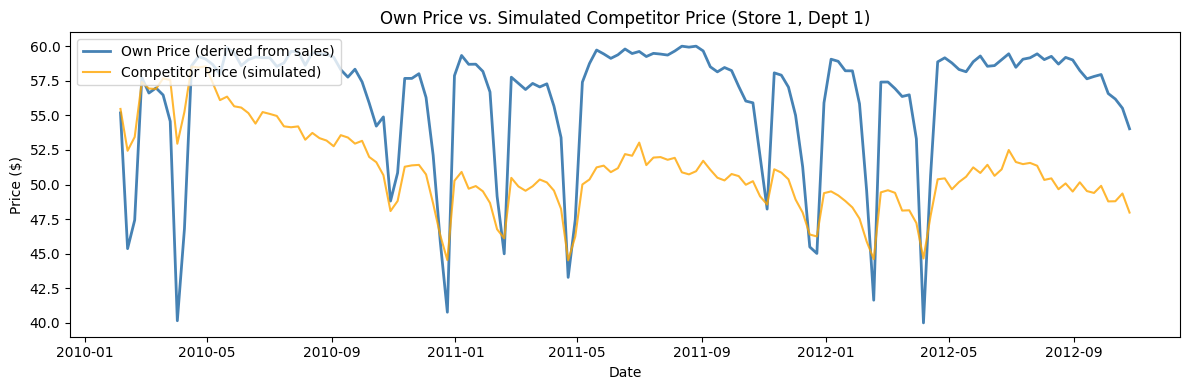

In [13]:
print("Competitor price simulation - documented assumptions:")
print("- Weekly volatility (random shock): 1.5%")
print("- Mean reversion: 30% pulled back toward own_price each week")
print("- Random seed: 42 (fully reproducible)")
print("- No real competitor data exists publicly at this granularity")
print("- This is standard practice in pricing modeling when external")
print("  price feeds are unavailable or proprietary")

plt.figure(figsize=(12, 4))
plt.plot(price_df["Date"], price_df["own_price"],
         label="Own Price (derived from sales)", linewidth=2, color="steelblue")
plt.plot(price_df["Date"], price_df["competitor_price"],
         label="Competitor Price (simulated)", linewidth=1.5, alpha=0.8, color="orange")
plt.title("Own Price vs. Simulated Competitor Price (Store 1, Dept 1)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("week1_day2_competitor_sim.png", dpi=150)
plt.show()